# EDA avanzado con yfinance (interactivo + valores por defecto)

Este notebook:

- descarga de datos con `yfinance`
- entrada por teclado de **tickers**, fechas e intervalo
- **valores por defecto** si no introduces nada
- control básico de errores
- calidad del dato: nulos, duplicados, cobertura temporal y outliers simples
- análisis OHLCV en formato **ancho** y **largo**
- retornos simples y logarítmicos
- volatilidad rolling
- drawdown
- correlaciones
- medias móviles
- rendimiento acumulado normalizado
- resumen final con métricas útiles para EDA financiero

## Qué he mantenido de tu trabajo
He respetado la idea de:
- usar `yfinance` como fuente
- poder elegir tickers por teclado
- convertir a formato largo
- revisar calidad del dato
- estudiar close, returns, volatilidad, drawdown, correlación y medias móviles

## Qué he mejorado
Además, este notebook incluye:
- entrada segura con *fallback* por defecto
- validación de tickers descargados
- resumen por ticker con más métricas
- comparación de series normalizadas a base 100
- distribución de retornos y percentiles extremos
- análisis mensual básico
- top/bottom días
- volatilidad y volumen anómalos
- guardado opcional de CSV por ticker

In [2]:
# Si lo necesitas:
# !pip install yfinance pandas numpy matplotlib

from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
pd.set_option("display.max_rows", 200)

DATA_DIR = Path("./data")
RAW_DIR = DATA_DIR / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)

print("OK - entorno listo")

ModuleNotFoundError: No module named 'matplotlib'

## 1) Parámetros interactivos con valores por defecto

Este bloque intenta pedir datos por teclado.  
Si ejecutas el notebook en un entorno donde `input()` no funciona bien, seguirá con valores por defecto.


In [ ]:
DEFAULT_TICKERS = ["SPY", "QQQ", "^GSPC", "^VIX"]
DEFAULT_START = "2015-01-01"
DEFAULT_END = None
DEFAULT_INTERVAL = "1d"
DEFAULT_FOCUS = "SPY"
DEFAULT_SAVE_CSV = "n"

def safe_input(prompt: str, default: str | None = None):
    try:
        value = input(prompt)
        if value is None:
            return default
        value = value.strip()
        return value if value != "" else default
    except Exception:
        return default

tickers_in = safe_input(
    f"Introduce tickers separados por coma [{', '.join(DEFAULT_TICKERS)}]: ",
    ", ".join(DEFAULT_TICKERS)
)

TICKERS = [t.strip() for t in tickers_in.split(",") if t.strip()]
START = safe_input(f"START (YYYY-MM-DD) [{DEFAULT_START}]: ", DEFAULT_START)
END = safe_input("END (YYYY-MM-DD) [vacío = hasta hoy]: ", None)
INTERVAL = safe_input(f"INTERVAL (1d,1wk,1mo,1h,...) [{DEFAULT_INTERVAL}]: ", DEFAULT_INTERVAL)
FOCUS_TICKER = safe_input(f"Ticker principal para análisis individual [{DEFAULT_FOCUS}]: ", DEFAULT_FOCUS)
SAVE_CSV = safe_input(f"¿Guardar CSV por ticker? (s/n) [{DEFAULT_SAVE_CSV}]: ", DEFAULT_SAVE_CSV)

print("TICKERS:", TICKERS)
print("START:", START)
print("END:", END)
print("INTERVAL:", INTERVAL)
print("FOCUS_TICKER:", FOCUS_TICKER)
print("SAVE_CSV:", SAVE_CSV)

TICKERS: ['SPY', 'QQQ', '^GSPC', '^VIX']
START: 2015-01-01
END: None
INTERVAL: 1d
FOCUS_TICKER: SPY
SAVE_CSV: s


## 2) Descarga de datos

In [ ]:
raw = yf.download(
    tickers=TICKERS,
    start=START,
    end=END, 
    interval=INTERVAL, # Intervalo temporal por el que buscamos los datos
    group_by="ticker", # Organiza la salida cuando descargas varios tickers
    auto_adjust=False, # TRUE: precios ajustados, FALSE: precios originales
    threads=True, # Poder descargar varios tickers en paralelo
    progress=False # Controla si aparece la barra de progreso en pantalla
)

print("Shape raw:", raw.shape)
raw.tail()

Shape raw: (2811, 24)


Ticker            ^GSPC                                                                         ^VIX                                                            QQQ              \
Price              Open         High          Low        Close    Adj Close        Volume       Open       High        Low      Close  Adj Close Volume        Open        High   
Date                                                                                                                                                                              
2026-03-03  6800.259766  6840.049805  6710.419922  6816.629883  6816.629883  6.442080e+09  24.570000  28.150000  22.180000  23.570000  23.570000      0  596.330017  603.960022   
2026-03-04  6831.689941  6885.939941  6811.640137  6869.500000  6869.500000  5.252170e+09  24.389999  24.870001  20.400000  21.150000  21.150000      0  604.159973  612.880005   
2026-03-05  6851.080078  6870.430176  6770.779785  6830.709961  6830.709961  5.989300e+09  22.110001  25.840000  20.549999  23.750000  23.750000      0  607.400024  612.760010   
2026-03-06  6769.029785  6773.419922  6711.560059  6740.020020  6740.020020  5.793120e+09  23.200001  29.930000  22.920000  29.490000  29.490000      0  600.309998  606.000000   
2026-03-09          NaN          NaN          NaN          NaN          NaN           NaN  35.119999  35.299999  33.119999  33.380001  33.380001      0         NaN         NaN   

Ticker                                                             SPY                                                               
Price              Low       Close   Adj Close      Volume        Open        High         Low       Close   Adj Close       Volume  
Date                                                                                                                                 
2026-03-03  591.869995  601.580017  601.580017  97015500.0  675.059998  682.609985  669.659973  680.330017  680.330017  105003100.0  
2026-03-04  603.429993  610.750000  610.750000  70943900.0  681.630005  687.090027  679.619995  685.130005  685.130005   79182200.0  
2026-03-05  602.260010  608.909973  608.909973  89602400.0  682.080017  685.530029  675.609985  681.309998  681.309998  106606500.0  
2026-03-06  598.330017  599.750000  599.750000  86221800.0  673.409973  676.109985  669.760010  672.380005  672.380005  100509800.0  
2026-03-09         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN          NaN

In [ ]:
def available_tickers(raw_df: pd.DataFrame, requested: list[str]) -> list[str]:
    if raw_df.empty:
        return []
    if isinstance(raw_df.columns, pd.MultiIndex):
        found = sorted(set(c[0] for c in raw_df.columns))
        return [t for t in requested if t in found]
    return requested[:1]

VALID_TICKERS = available_tickers(raw, TICKERS)

if not VALID_TICKERS:
    raise ValueError("No se han descargado datos válidos. Revisa los tickers, fechas o intervalo.")

if FOCUS_TICKER not in VALID_TICKERS:
    FOCUS_TICKER = VALID_TICKERS[0]

print("Tickers válidos descargados:", VALID_TICKERS)
print("Ticker principal usado:", FOCUS_TICKER)


Tickers válidos descargados: ['SPY', 'QQQ', '^GSPC', '^VIX']
Ticker principal usado: SPY


## 3) Funciones auxiliares

In [ ]:
def to_long_ohlcv(raw_df: pd.DataFrame) -> pd.DataFrame:
    if isinstance(raw_df.columns, pd.MultiIndex):
        pieces = []
        for t in sorted(set(c[0] for c in raw_df.columns)):
            sub = raw_df[t].copy()
            sub = sub.rename(columns={"Adj Close": "Adj_Close"})
            sub["Ticker"] = t
            pieces.append(sub.reset_index())
        df = pd.concat(pieces, ignore_index=True)
    else:
        df = raw_df.copy().reset_index()
        df = df.rename(columns={"Adj Close": "Adj_Close"})
        df["Ticker"] = VALID_TICKERS[0]
    cols = ["Date", "Ticker"] + [c for c in df.columns if c not in ["Date", "Ticker"]]
    return df[cols]

def get_close_wide(raw_df: pd.DataFrame, tickers: list[str]) -> pd.DataFrame:
    if isinstance(raw_df.columns, pd.MultiIndex):
        close = pd.DataFrame({t: raw_df[(t, "Close")] for t in tickers if (t, "Close") in raw_df.columns})
    else:
        close = raw_df[["Close"]].rename(columns={"Close": tickers[0]})
    return close.sort_index()

def get_volume_wide(raw_df: pd.DataFrame, tickers: list[str]) -> pd.DataFrame:
    if isinstance(raw_df.columns, pd.MultiIndex):
        volume = pd.DataFrame({t: raw_df[(t, "Volume")] for t in tickers if (t, "Volume") in raw_df.columns})
    else:
        volume = raw_df[["Volume"]].rename(columns={"Volume": tickers[0]})
    return volume.sort_index()

def compute_drawdown(price: pd.Series) -> pd.DataFrame:
    s = price.dropna().copy()
    cummax = s.cummax()
    dd = s / cummax - 1.0
    return pd.DataFrame({"price": s, "cummax": cummax, "drawdown": dd})

def data_quality_report(df: pd.DataFrame) -> pd.DataFrame:
    rep = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_missing": df.isna().sum(),
        "pct_missing": (df.isna().mean() * 100).round(3),
        "n_unique": df.nunique(dropna=True),
    })
    return rep.sort_values(["pct_missing", "n_missing"], ascending=False)

def annualization_factor(interval: str) -> int:
    interval = str(interval).lower()
    if interval.endswith("d"):
        return 252
    if interval.endswith("wk"):
        return 52
    if interval.endswith("mo"):
        return 12
    if interval.endswith("h"):
        return 252 * 6
    return 252

def rolling_window(interval: str) -> int:
    interval = str(interval).lower()
    if interval.endswith("d"):
        return 21
    if interval.endswith("wk"):
        return 8
    if interval.endswith("mo"):
        return 6
    if interval.endswith("h"):
        return 24
    return 21

def save_raw_per_ticker(raw_df: pd.DataFrame, tickers: list[str], out_dir: Path, interval: str) -> None:
    if isinstance(raw_df.columns, pd.MultiIndex):
        for t in tickers:
            cols = [c for c in raw_df.columns if c[0] == t]
            if not cols:
                continue
            sub = raw_df[cols].copy()
            sub.columns = [c[1] for c in cols]
            sub.to_csv(out_dir / f"{t.replace('^','_')}_{interval}.csv", index=True)
    else:
        raw_df.to_csv(out_dir / f"{tickers[0].replace('^','_')}_{interval}.csv", index=True)


## 4) Formato largo y primera inspección

In [ ]:
df_long = to_long_ohlcv(raw)
df_long["Date"] = pd.to_datetime(df_long["Date"], errors="coerce")
df_long = df_long.sort_values(["Ticker", "Date"]).reset_index(drop=True)

print("Shape largo:", df_long.shape)
print(df_long.head())
print(df_long.tail())

Shape largo: (11244, 8)
Price       Date Ticker        Open        High         Low       Close  Adj_Close      Volume
0     2015-01-02    QQQ  103.760002  104.199997  102.440002  102.940002  94.784416  31314600.0
1     2015-01-05    QQQ  102.489998  102.610001  101.139999  101.430000  93.394066  36521300.0
2     2015-01-06    QQQ  101.580002  101.750000   99.620003  100.070000  92.141815  66205500.0
3     2015-01-07    QQQ  100.730003  101.599998  100.489998  101.360001  93.329597  37577400.0
4     2015-01-08    QQQ  102.220001  103.500000  102.110001  103.300003  95.115891  40212600.0
Price       Date Ticker       Open       High        Low      Close  Adj_Close  Volume
11239 2026-03-03   ^VIX  24.570000  28.150000  22.180000  23.570000  23.570000     0.0
11240 2026-03-04   ^VIX  24.389999  24.870001  20.400000  21.150000  21.150000     0.0
11241 2026-03-05   ^VIX  22.110001  25.840000  20.549999  23.750000  23.750000     0.0
11242 2026-03-06   ^VIX  23.200001  29.930000  22.920000  

In [ ]:
close = get_close_wide(raw, VALID_TICKERS)
volume = get_volume_wide(raw, VALID_TICKERS)

ret = close.pct_change()
logret = np.log(close).diff()

ANN_FACTOR = annualization_factor(INTERVAL)
ROLL = rolling_window(INTERVAL)
vol = logret.rolling(ROLL).std() * np.sqrt(ANN_FACTOR)

print("Shape close:", close.shape)
print("Factor anualización:", ANN_FACTOR)
print("Ventana rolling:", ROLL)
close.tail()


Shape close: (2811, 4)
Factor anualización: 252
Ventana rolling: 21


,SPY,QQQ,^GSPC,^VIX
Date,,,,
2026-03-03,680.330017,601.580017,6816.629883,23.570000
2026-03-04,685.130005,610.750000,6869.500000,21.150000
2026-03-05,681.309998,608.909973,6830.709961,23.750000
2026-03-06,672.380005,599.750000,6740.020020,29.490000
2026-03-09,NaN,NaN,NaN,33.380001


## 5) Calidad del dato

In [ ]:
print("Duplicados completos:", int(df_long.duplicated().sum()))
print("Duplicados por (Date, Ticker):", int(df_long.duplicated(subset=["Date", "Ticker"]).sum()))
data_quality_report(df_long)


Duplicados completos: 0
Duplicados por (Date, Ticker): 0


,dtype,n_missing,pct_missing,n_unique
Price,,,,
Open,float64,3,0.027,9521
High,float64,3,0.027,9607
Low,float64,3,0.027,9518
Close,float64,3,0.027,9559
Adj_Close,float64,3,0.027,9805
Volume,float64,3,0.027,8406
Date,datetime64[ns],0,0.000,2811
Ticker,object,0,0.000,4


In [ ]:
coverage = (
    df_long.groupby("Ticker")
    .agg(
        start=("Date", "min"),
        end=("Date", "max"),
        n_obs=("Date", "count"),
        missing_close=("Close", lambda s: int(s.isna().sum())),
        missing_volume=("Volume", lambda s: int(s.isna().sum()) if "Volume" in df_long.columns else np.nan),
    )
)

coverage["years_covered"] = ((coverage["end"] - coverage["start"]).dt.days / 365.25).round(2)
coverage


,start,end,n_obs,missing_close,missing_volume,years_covered
Ticker,,,,,,
QQQ,2015-01-02,2026-03-09,2811,1,1,11.18
SPY,2015-01-02,2026-03-09,2811,1,1,11.18
^GSPC,2015-01-02,2026-03-09,2811,1,1,11.18
^VIX,2015-01-02,2026-03-09,2811,0,0,11.18


## 6) Estadística descriptiva por ticker

In [ ]:
numeric_cols = [c for c in df_long.columns if c not in ["Date", "Ticker"]]
desc = (
    df_long
    .groupby("Ticker")[numeric_cols]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
)
desc


Price     Open                                                                                                                                                   High  \
         count         mean          std          min           1%           5%          25%          50%          75%          95%          99%          max   count   
Ticker                                                                                                                                                                  
QQQ     2810.0   276.966719   147.913176    94.230003   101.718099   106.309002   147.827507   263.090012   370.629997   570.427518   622.225593   635.590027  2810.0   
SPY     2810.0   365.851039   137.243901   182.339996   191.970806   204.704501   249.615002   331.900009   447.135010   638.322977   687.920995   697.049988  2810.0   
^GSPC   2810.0  3665.585691  1378.156953  1833.400024  1919.840824  2047.868994  2499.802429  3327.464966  4480.739990  6403.770459  6903.388589  7002.000000  2810.0   
^VIX    2811.0    18.500441     7.148199     9.010000     9.740000    10.975000    13.760000    16.709999    21.545000    30.974999    44.085000    82.690002  2811.0   

Price                                                                                                                                                     Low               \
               mean          std          min           1%           5%          25%          50%          75%          95%          99%          max   count         mean   
Ticker                                                                                                                                                                       
QQQ      278.947751   148.864027    97.050003   102.582702   106.974502   148.209995   265.920013   372.864998   573.306494   624.932801   637.010010  2810.0   274.787687   
SPY      367.821655   137.881497   184.100006   193.457197   205.963496   251.237507   333.774994   449.387512   640.201984   690.054598   697.840027  2810.0   363.697188   
^GSPC   3684.986700  1384.689705  1847.000000  1935.786826  2060.619006  2513.672485  3341.234985  4502.257446  6422.304028  6920.376279  7002.279785  2810.0  3644.530216   
^VIX      19.609036     7.963675     9.310000    10.081000    11.490000    14.310000    17.610001    22.799999    33.040001    49.309000    85.470001  2811.0    17.473924   

Price                                                                                                                                      Close                            \
                std          min           1%           5%          25%          50%          75%          95%          99%          max   count         mean          std   
Ticker                                                                                                                                                                       
QQQ      146.787924    84.739998   100.480903   105.830002   146.990005   259.915009   368.075005   566.806989   618.442922   631.809998  2810.0   277.017167   147.897459   
SPY      136.505126   181.020004   189.820007   203.884502   248.532505   330.835007   444.745010   635.260980   684.321180   693.940002  2810.0   365.916577   137.267644   
^GSPC   1370.968501  1810.099976  1897.425940  2040.887457  2490.615112  3316.990112  4457.452637  6372.522925  6861.841021  6963.459961  2810.0  3666.167290  1378.426734   
^VIX       6.389282     8.560000     9.371000    10.400000    13.190000    15.960000    20.180000    28.760000    39.879001    70.370003  2811.0    18.336418     7.087643   

Price                                                                                                                       Adj_Close                                         \
                min           1%           5%          25%          50%          75%          95%          99%          max     count         mean          std          min   
Ticker                    

## 7) Gráficos básicos de precio y volumen

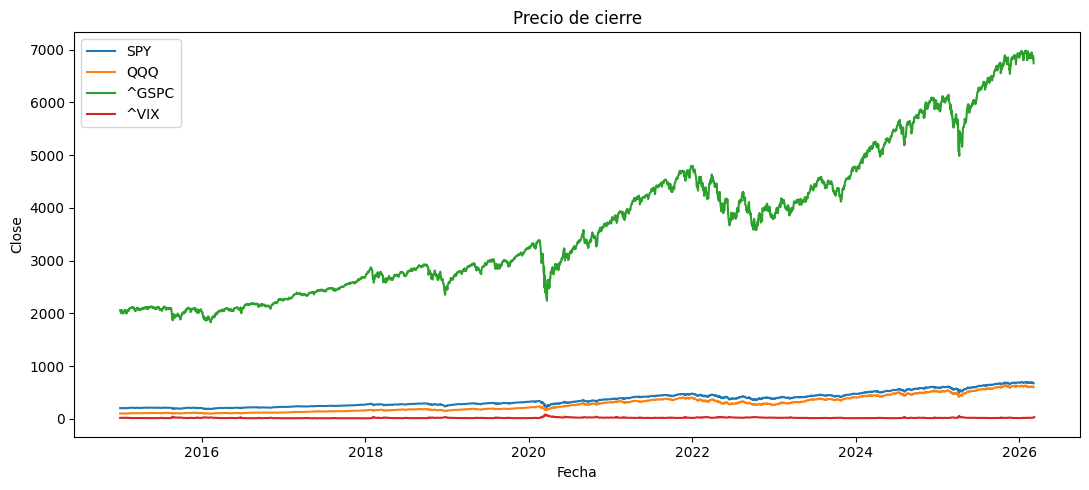

In [ ]:
plt.figure(figsize=(11, 5))
for t in VALID_TICKERS:
    if t in close.columns:
        plt.plot(close.index, close[t], label=t)
plt.title("Precio de cierre")
plt.xlabel("Fecha")
plt.ylabel("Close")
plt.legend()
plt.tight_layout()
plt.show()


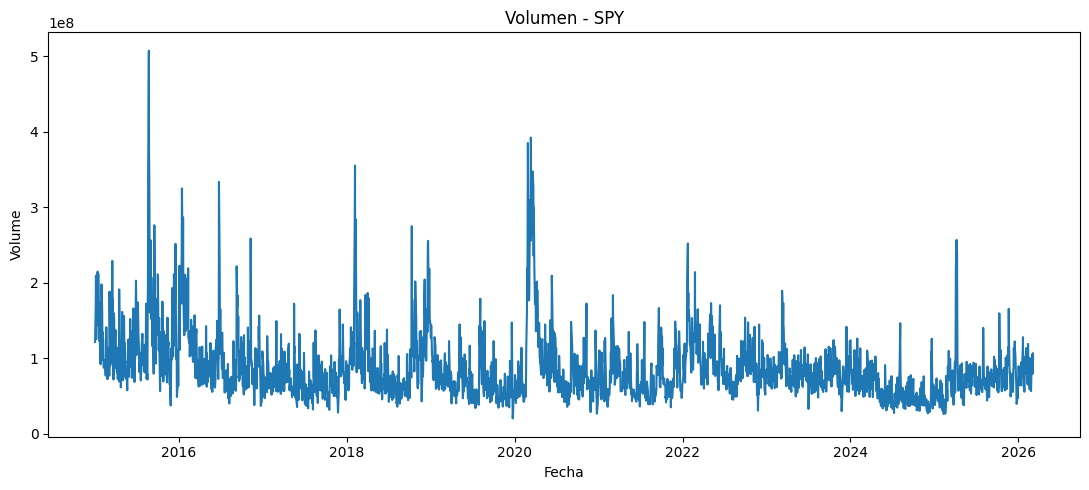

In [ ]:
plt.figure(figsize=(11, 5))
if FOCUS_TICKER in volume.columns:
    plt.plot(volume.index, volume[FOCUS_TICKER])
    plt.title(f"Volumen - {FOCUS_TICKER}")
    plt.xlabel("Fecha")
    plt.ylabel("Volume")
    plt.tight_layout()
    plt.show()


## 8) Series normalizadas a base 100

Esto permite comparar activos con escalas de precios distintas.


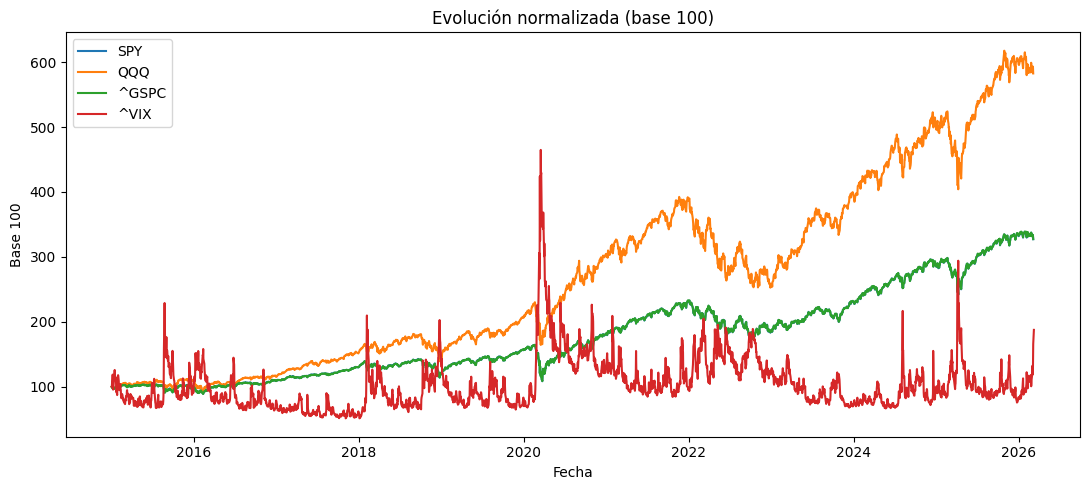

,SPY,QQQ,^GSPC,^VIX
Date,,,,
2026-03-03,331.173656,584.398682,331.193764,132.490154
2026-03-04,333.510212,593.306767,333.762519,118.887007
2026-03-05,331.650695,591.519292,331.877860,133.501961
2026-03-06,327.303718,582.620930,327.471586,165.767275
2026-03-09,NaN,NaN,NaN,187.633498


In [ ]:
norm_close = close.divide(close.iloc[0]).mul(100)

plt.figure(figsize=(11, 5))
for t in norm_close.columns:
    plt.plot(norm_close.index, norm_close[t], label=t)
plt.title("Evolución normalizada (base 100)")
plt.xlabel("Fecha")
plt.ylabel("Base 100")
plt.legend()
plt.tight_layout()
plt.show()

norm_close.tail()


## 9) Retornos, distribución y extremos

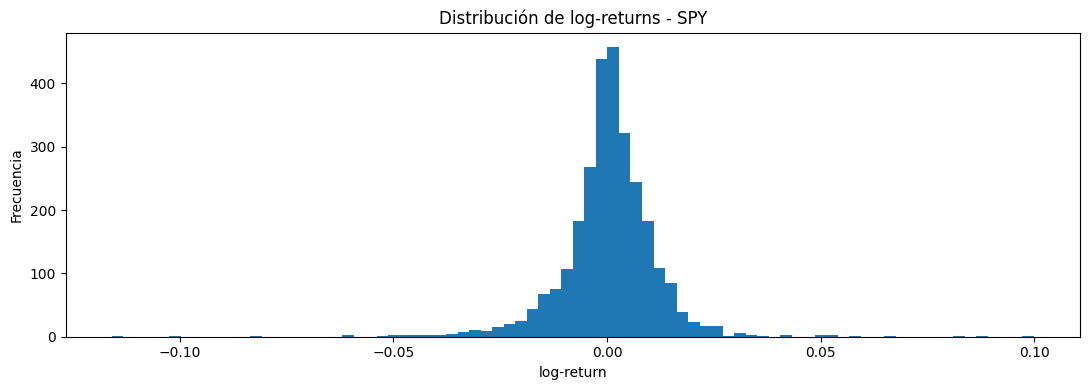

,value
mean,0.000422
std,0.011226
skew,-0.580481
kurtosis,14.409895
p01,-0.032512
p05,-0.016877
median,0.000596
p95,0.015426
p99,0.025829


In [ ]:
ticker_focus = FOCUS_TICKER
vals = logret[ticker_focus].dropna()

fig = plt.figure(figsize=(11, 4))
plt.hist(vals, bins=80)
plt.title(f"Distribución de log-returns - {ticker_focus}")
plt.xlabel("log-return")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

moments = pd.Series({
    "mean": float(vals.mean()),
    "std": float(vals.std()),
    "skew": float(vals.skew()),
    "kurtosis": float(vals.kurtosis()),
    "p01": float(vals.quantile(0.01)),
    "p05": float(vals.quantile(0.05)),
    "median": float(vals.quantile(0.50)),
    "p95": float(vals.quantile(0.95)),
    "p99": float(vals.quantile(0.99)),
})
moments.to_frame("value")


In [ ]:
extreme_days = (
    logret[ticker_focus]
    .dropna()
    .sort_values()
    .to_frame("log_return")
)

print("Peores 10 días:")
display(extreme_days.head(10))

print("Mejores 10 días:")
display(extreme_days.tail(10).sort_values("log_return", ascending=False))


Peores 10 días:


,log_return
Date,
2020-03-16,-0.115887
2020-03-12,-0.100569
2020-03-09,-0.081313
2025-04-04,-0.060327
2020-06-11,-0.059377
2020-03-18,-0.051960
2025-04-03,-0.050537
2020-03-11,-0.049977
2020-03-20,-0.049913


Mejores 10 días:


,log_return
Date,
2025-04-09,0.099863
2020-03-24,0.086731
2020-03-13,0.082028
2020-04-06,0.065007
2020-03-26,0.056749
2022-11-10,0.053497
2020-03-17,0.052585
2020-03-10,0.050451
2018-12-26,0.049290


## 10) Volatilidad rolling y drawdown

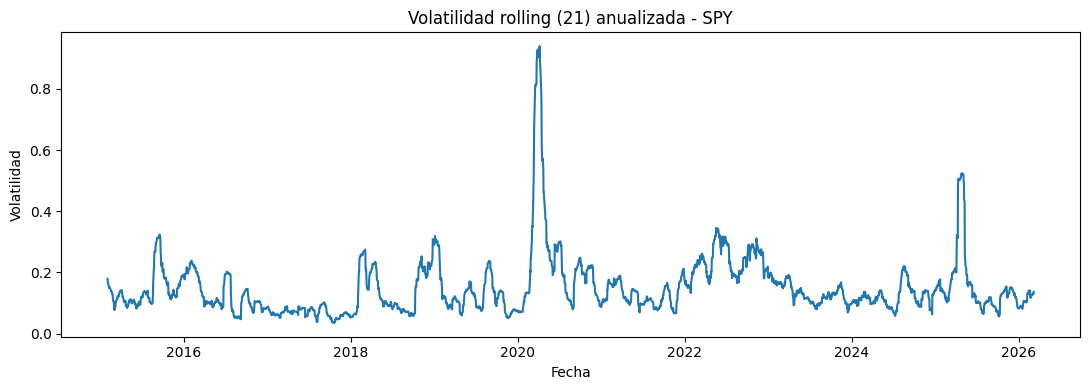

In [ ]:
plt.figure(figsize=(11, 4))
plt.plot(vol.index, vol[ticker_focus])
plt.title(f"Volatilidad rolling ({ROLL}) anualizada - {ticker_focus}")
plt.xlabel("Fecha")
plt.ylabel("Volatilidad")
plt.tight_layout()
plt.show()


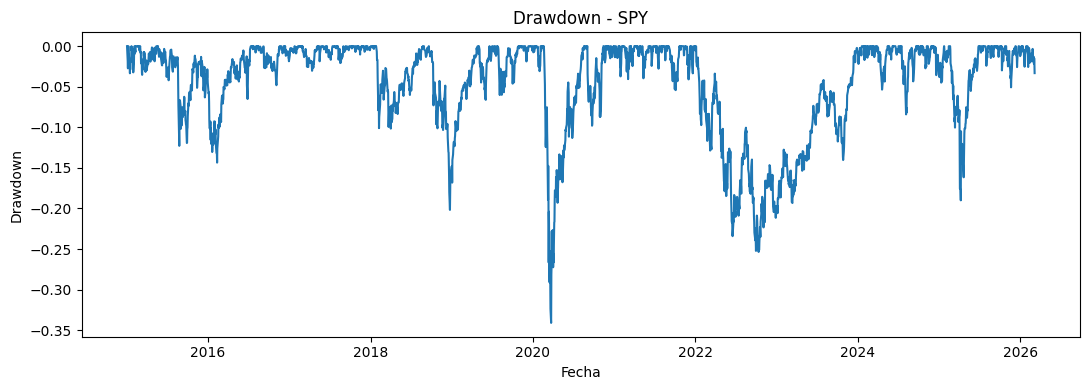

,drawdown
count,2810.000000
mean,-0.046378
std,0.057872
min,-0.341047
25%,-0.069006
50%,-0.020852
75%,-0.004148
max,0.000000


In [ ]:
dd = compute_drawdown(close[ticker_focus])

plt.figure(figsize=(11, 4))
plt.plot(dd.index, dd["drawdown"])
plt.title(f"Drawdown - {ticker_focus}")
plt.xlabel("Fecha")
plt.ylabel("Drawdown")
plt.tight_layout()
plt.show()

dd["drawdown"].describe().to_frame("drawdown")


## 11) Correlación entre activos

In [ ]:
corr = logret.dropna().corr()
corr


,SPY,QQQ,^GSPC,^VIX
SPY,1.000000,0.932686,0.997251,-0.739246
QQQ,0.932686,1.000000,0.933628,-0.712325
^GSPC,0.997251,0.933628,1.000000,-0.739922
^VIX,-0.739246,-0.712325,-0.739922,1.000000


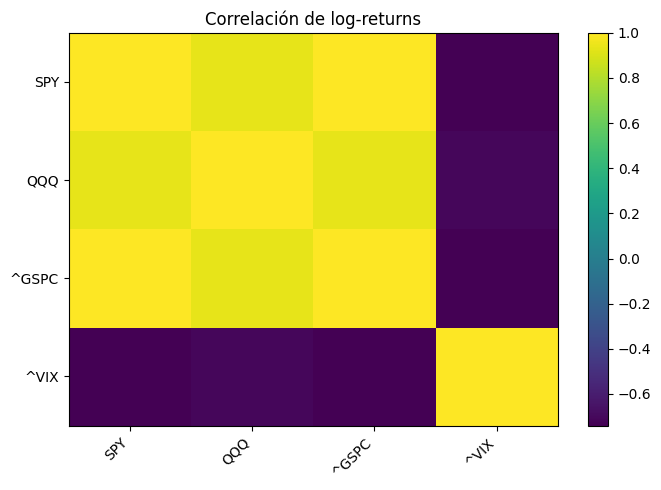

In [ ]:
plt.figure(figsize=(7, 5))
plt.imshow(corr.values, aspect="auto")
plt.title("Correlación de log-returns")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar()
plt.tight_layout()
plt.show()


## 12) Señal simple de tendencia: medias móviles

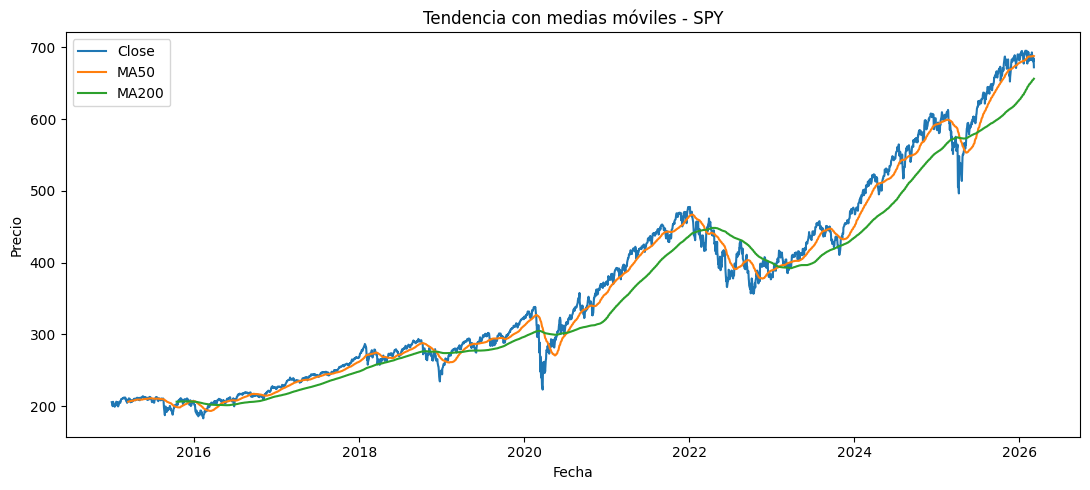

,n_periodos
SPY,
Bullish,2072
Bearish,739


In [ ]:
SHORT = 50
LONG = 200

ma_s = close[ticker_focus].rolling(SHORT).mean()
ma_l = close[ticker_focus].rolling(LONG).mean()
signal = (ma_s > ma_l).astype(int)

plt.figure(figsize=(11, 5))
plt.plot(close.index, close[ticker_focus], label="Close")
plt.plot(ma_s.index, ma_s, label=f"MA{SHORT}")
plt.plot(ma_l.index, ma_l, label=f"MA{LONG}")
plt.title(f"Tendencia con medias móviles - {ticker_focus}")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
plt.tight_layout()
plt.show()

signal.value_counts().rename(index={0: "Bearish", 1: "Bullish"}).to_frame("n_periodos")


## 13) Análisis mensual básico

Útil para ver estacionalidad simple y dispersión mensual.


In [ ]:
monthly_ret = close.resample("M").last().pct_change()
monthly_summary = pd.DataFrame({
    "mean_monthly_return": monthly_ret.mean(),
    "std_monthly_return": monthly_ret.std(),
    "best_month": monthly_ret.max(),
    "worst_month": monthly_ret.min(),
    "positive_month_ratio": (monthly_ret > 0).mean()
}).sort_values("mean_monthly_return", ascending=False)

monthly_summary


,mean_monthly_return,std_monthly_return,best_month,worst_month,positive_month_ratio
^VIX,0.035774,0.277109,1.345710,-0.458969,0.481481
QQQ,0.014738,0.052481,0.149737,-0.135957,0.637037
SPY,0.010041,0.043214,0.126984,-0.129987,0.659259
^GSPC,0.010041,0.042845,0.126844,-0.125119,0.659259


In [ ]:
if ticker_focus in monthly_ret.columns:
    monthly_focus = monthly_ret[ticker_focus].dropna().to_frame("monthly_return")
    monthly_focus["year"] = monthly_focus.index.year
    monthly_focus["month"] = monthly_focus.index.month

    pivot_month = monthly_focus.pivot_table(index="year", columns="month", values="monthly_return", aggfunc="mean")
    pivot_month


## 14) Volumen y días anómalos

In [ ]:
if ticker_focus in volume.columns:
    vol_focus = volume[ticker_focus].dropna()
    vol_z = (vol_focus - vol_focus.mean()) / vol_focus.std() if vol_focus.std() != 0 else vol_focus * np.nan
    unusual_volume = vol_z[vol_z > 3].sort_values(ascending=False).to_frame("zscore_volume")
    unusual_volume.head(15)


## 15) Tabla resumen final por ticker

In [ ]:
summary_rows = []

for t in close.columns:
    s = close[t].dropna()
    if len(s) < 30:
        continue

    lr = np.log(s).diff().dropna()
    r = s.pct_change().dropna()
    dd_t = compute_drawdown(s)["drawdown"]

    ann_ret = lr.mean() * ANN_FACTOR
    ann_vol = lr.std() * np.sqrt(ANN_FACTOR)
    sharpe_like = ann_ret / ann_vol if ann_vol != 0 else np.nan

    summary_rows.append({
        "Ticker": t,
        "start": s.index.min().date(),
        "end": s.index.max().date(),
        "n_obs": int(len(s)),
        "last_close": float(s.iloc[-1]),
        "total_return": float(s.iloc[-1] / s.iloc[0] - 1),
        "ann_log_return": float(ann_ret),
        "ann_vol": float(ann_vol),
        "sharpe_like": float(sharpe_like) if pd.notna(sharpe_like) else np.nan,
        "max_drawdown": float(dd_t.min()),
        "best_day": float(r.max()) if len(r) else np.nan,
        "worst_day": float(r.min()) if len(r) else np.nan,
        "pct_positive_days": float((r > 0).mean()) if len(r) else np.nan,
        "skew_logret": float(lr.skew()) if len(lr) else np.nan,
        "kurtosis_logret": float(lr.kurtosis()) if len(lr) else np.nan,
    })

summary = pd.DataFrame(summary_rows).sort_values(["sharpe_like", "ann_log_return"], ascending=False)
summary


,Ticker,start,end,n_obs,last_close,total_return,ann_log_return,ann_vol,sharpe_like,max_drawdown,best_day,worst_day,pct_positive_days,skew_logret,kurtosis_logret
1,QQQ,2015-01-02,2026-03-06,2810,599.750000,4.826209,0.158105,0.219442,0.720485,-0.356172,0.120031,-0.119788,0.558918,-0.387795,7.773496
0,SPY,2015-01-02,2026-03-06,2810,672.380005,2.273037,0.106373,0.178204,0.596917,-0.341047,0.105019,-0.109424,0.545034,-0.580481,14.409895
2,^GSPC,2015-01-02,2026-03-06,2810,6740.020020,2.274716,0.106419,0.178789,0.595220,-0.339250,0.095154,-0.119841,0.540406,-0.653130,15.963946
3,^VIX,2015-01-02,2026-03-09,2811,33.380001,0.876335,0.056437,1.281732,0.044032,-0.856573,1.155979,-0.357539,0.452313,1.236780,7.546557


## 16) Guardado opcional de CSV

Guarda un CSV bruto por ticker si lo has indicado.


In [ ]:
if str(SAVE_CSV).lower() in {"s", "si", "sí", "y", "yes"}:
    save_raw_per_ticker(raw, VALID_TICKERS, RAW_DIR, INTERVAL)
    print("CSV guardados en:", RAW_DIR.resolve())
else:
    print("No se han guardado CSV.")


CSV guardados en: C:\Users\usuario\Desktop\tfm\notebooks\data\raw


## 17) Conclusiones guía para interpretar el EDA

Cuando ejecutes el notebook, fíjate especialmente en:

1. **Cobertura temporal y nulos**  
   Si un ticker tiene pocos datos o muchos nulos, puede distorsionar las comparaciones.

2. **Retorno vs volatilidad**  
   No basta con mirar quién sube más; mira también la volatilidad y el drawdown.

3. **Distribución de retornos**  
   La asimetría (*skew*) y curtosis ayudan a ver si hay colas pesadas o eventos extremos.

4. **Correlación**  
   Dos activos muy correlacionados aportan poca diversificación.

5. **Drawdown máximo**  
   Es una métrica muy útil para estudiar periodos de crisis o estrés.

6. **Serie normalizada**  
   Ideal para comparar comportamientos relativos aunque los precios absolutos sean muy distintos.

7. **Meses y días extremos**  
   Ayudan a identificar periodos de régimen, shocks o cambios de mercado.
